## Prédiction de reussite scolaire

## ⚙️ Régression logistique et algorithme de scoring 

### ➡️ Chargement des librairies et de notre dataset 

In [21]:
import pandas as pd
import numpy as np

np.long = np.int_
np.ulong = np.int64

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

data = pd.read_csv("Data/dataset_S7.csv")

print(data.head())
print(data.dtypes)

   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   
3                           1                       1            1   
4                           0                       1            1   

   Mother's qualification  Father's qualification  Mother's occupation  ...  \
0                      13                      10                    6  ...   
1                       

### ➡️ Features et cible 

In [ ]:
# Recodage de Target : Dropout = 1, autres = 0
data["Target_bin"] = data["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

X = data.drop(columns=["Target", "Target_bin"])
y = data["Target_bin"]

### ➡️ Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### ➡️ Modèle 

In [22]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)

# Prédictions
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print("ROC-AUC :", roc_auc)

ROC-AUC : 0.9290208806918047


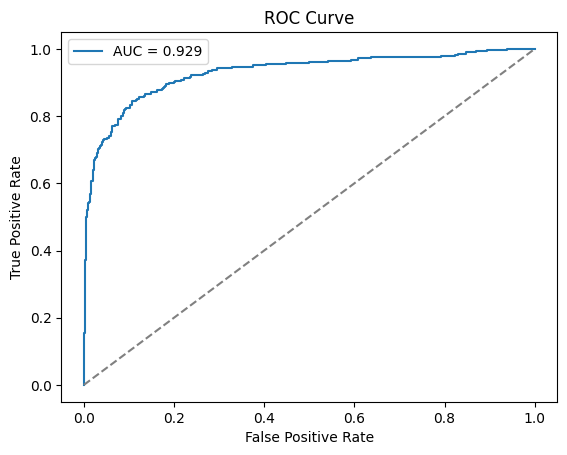

In [24]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ➡️ Score de risque d'abandon

In [8]:
data_score = pd.DataFrame({
    "Score_risque_abandon": (y_proba * 100).round(1),
    "Target_reelle": y_test.reset_index(drop=True)
})

print(data_score.head())

   Score_risque_abandon  Target_reelle
0                   5.9              0
1                  35.1              0
2                  97.7              1
3                   4.6              0
4                  98.3              1


### ➡️ Résumé

La régression logistique atteint une AUC de 0.93, révélant une excellente capacité à distinguer les étudiants à risque d’abandon. Les scores prédits sont cohérents avec les trajectoires réelles : les abandons affichent des probabilités proches de 100 %, tandis que les étudiants poursuivant leur cursus restent autour de 5 %.
Un modèle simple, interprétable, mais déjà très efficace pour soutenir une démarche de prévention et d’accompagnement personnalisé.